# ECG5000 — Exploratory Data Analysis

## Dataset
- **Source**: UCR Time Series Classification Archive
- **Description**: 5,000 heartbeat recordings from a 20-hour ECG, pre-processed to equal length
- **Shape**: 140 timesteps per heartbeat (univariate time series)
- **Classes**: 5 (Normal + 4 arrhythmia types)
- **Purpose**: EDA to understand signal characteristics, class distribution, and preprocessing needs for RNN classification

## Reference
- [UCR Time Series Archive](https://www.cs.ucr.edu/~eamonn/time_series_data/)
- [ECG5000 Dataset Description](https://www.timeseriesclassification.com/description.php?Dataset=ECG5000)

In [2]:
# Step 1: Setup + Load ECG5000
"""
ECG5000 from the official UCR Time Series Classification Archive
Loaded via the aeon toolkit — maintained by the same team as the archive
Source: https://www.timeseriesclassification.com/description.php?Dataset=ECG5000
Original data from PhysioNet (http://physionet.org/)
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EDA_DIR = '../data/raw/eda_rnn'
Path(EDA_DIR).mkdir(parents=True, exist_ok=True)

# Install aeon if needed: pip install aeon
from aeon.datasets import load_classification

# Load ECG5000 — aeon downloads from the official UCR archive
X_train_raw, y_train_raw = load_classification("ECG5000", split="train")
X_test_raw, y_test_raw = load_classification("ECG5000", split="test")

# aeon returns shape (n_samples, n_channels, n_timesteps) — squeeze channel dim
# and convert labels to int
X_train_raw = X_train_raw.squeeze(1).astype(np.float32)
X_test_raw = X_test_raw.squeeze(1).astype(np.float32)
y_train_raw = y_train_raw.astype(int)
y_test_raw = y_test_raw.astype(int)

print("=" * 60)
print("ECG5000 — Exploratory Data Analysis")
print("=" * 60)
print(f"Train: {X_train_raw.shape} | Test: {X_test_raw.shape}")
print(f"Sequence length: {X_train_raw.shape[1]} timesteps")
print(f"Features per timestep: 1 (univariate ECG)")
print(f"Dtype: {X_train_raw.dtype}")
print(f"Value range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"Labels: {np.unique(y_train_raw)}")
print(f"Note: UCR default split is inverted (500 train / 4500 test)")

ECG5000 — Exploratory Data Analysis
Train: (500, 140) | Test: (4500, 140)
Sequence length: 140 timesteps
Features per timestep: 1 (univariate ECG)
Dtype: float32
Value range: [-5.7976, 4.0581]
Labels: [1 2 3 4 5]
Note: UCR default split is inverted (500 train / 4500 test)


C:\Users\Max\AppData\Local\Temp\ipykernel_30324\317161656.py:20: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train_raw, y_train_raw = load_classification("ECG5000", split="train")
C:\Users\Max\AppData\Local\Temp\ipykernel_30324\317161656.py:21: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test_raw, y_test_raw = load_classification("ECG5000", split="test")


[1/7] Class Distribution


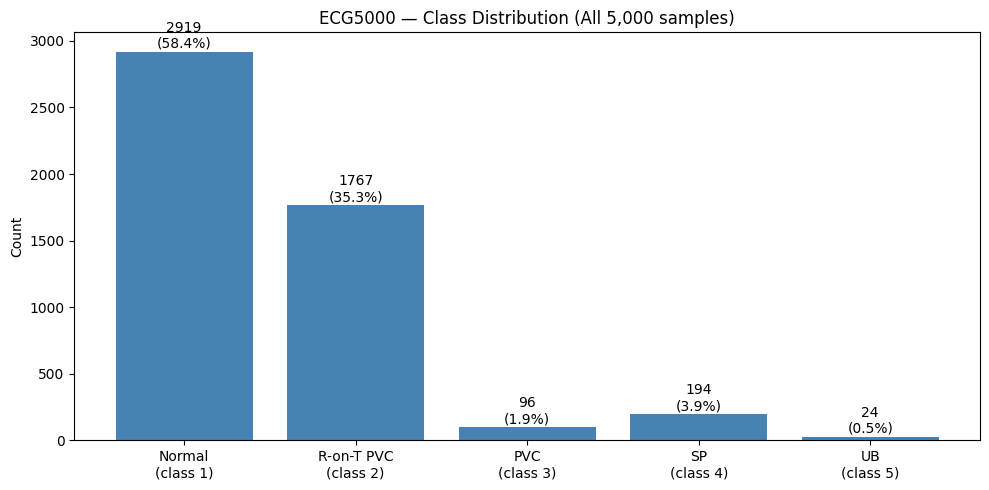


Total samples: 5,000

Per-class breakdown:
  Class 1 (Normal): 2,919 (58.4%)
  Class 2 (R-on-T PVC): 1,767 (35.3%)
  Class 3 (PVC): 96 (1.9%)
  Class 4 (SP): 194 (3.9%)
  Class 5 (UB): 24 (0.5%)

Imbalance ratio (max/min): 121.6x
Majority class: Normal (2,919)
Minority class: UB (24)

Class weights will be needed for training


In [3]:
# Step 2: [1/7] Class Distribution
"""
ECG5000 has 5 heartbeat classes — check for imbalance
UCR split is inverted (500 train / 4500 test), so analyze combined
Labels are 1-indexed: 1=Normal, 2-5=Abnormal variants
"""

# Combine all data for full picture
X_all = np.concatenate([X_train_raw, X_test_raw])
y_all = np.concatenate([y_train_raw, y_test_raw])

CLASS_NAMES = ['Normal', 'R-on-T PVC', 'PVC', 'SP', 'UB']
label_map = {1: 'Normal', 2: 'R-on-T PVC', 3: 'PVC', 4: 'SP', 5: 'UB'}

print("=" * 60)
print("[1/7] Class Distribution")
print("=" * 60)

# Per-class counts
unique, counts = np.unique(y_all, return_counts=True)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(unique)), counts, color='steelblue')
ax.set_xticks(range(len(unique)))
ax.set_xticklabels([f'{label_map[u]}\n(class {u})' for u in unique])
ax.set_ylabel('Count')
ax.set_title('ECG5000 — Class Distribution (All 5,000 samples)')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count}\n({count/len(y_all)*100:.1f}%)',
            ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imbalance analysis
print(f"\nTotal samples: {len(y_all):,}")
print(f"\nPer-class breakdown:")
for label, count in zip(unique, counts):
    pct = count / len(y_all) * 100
    print(f"  Class {label} ({label_map[label]}): {count:,} ({pct:.1f}%)")

imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.1f}x")
print(f"Majority class: {label_map[unique[counts.argmax()]]} ({counts.max():,})")
print(f"Minority class: {label_map[unique[counts.argmin()]]} ({counts.min():,})")
print(f"\nClass weights will be needed for training")

[2/7] Sample ECG Waveforms by Class


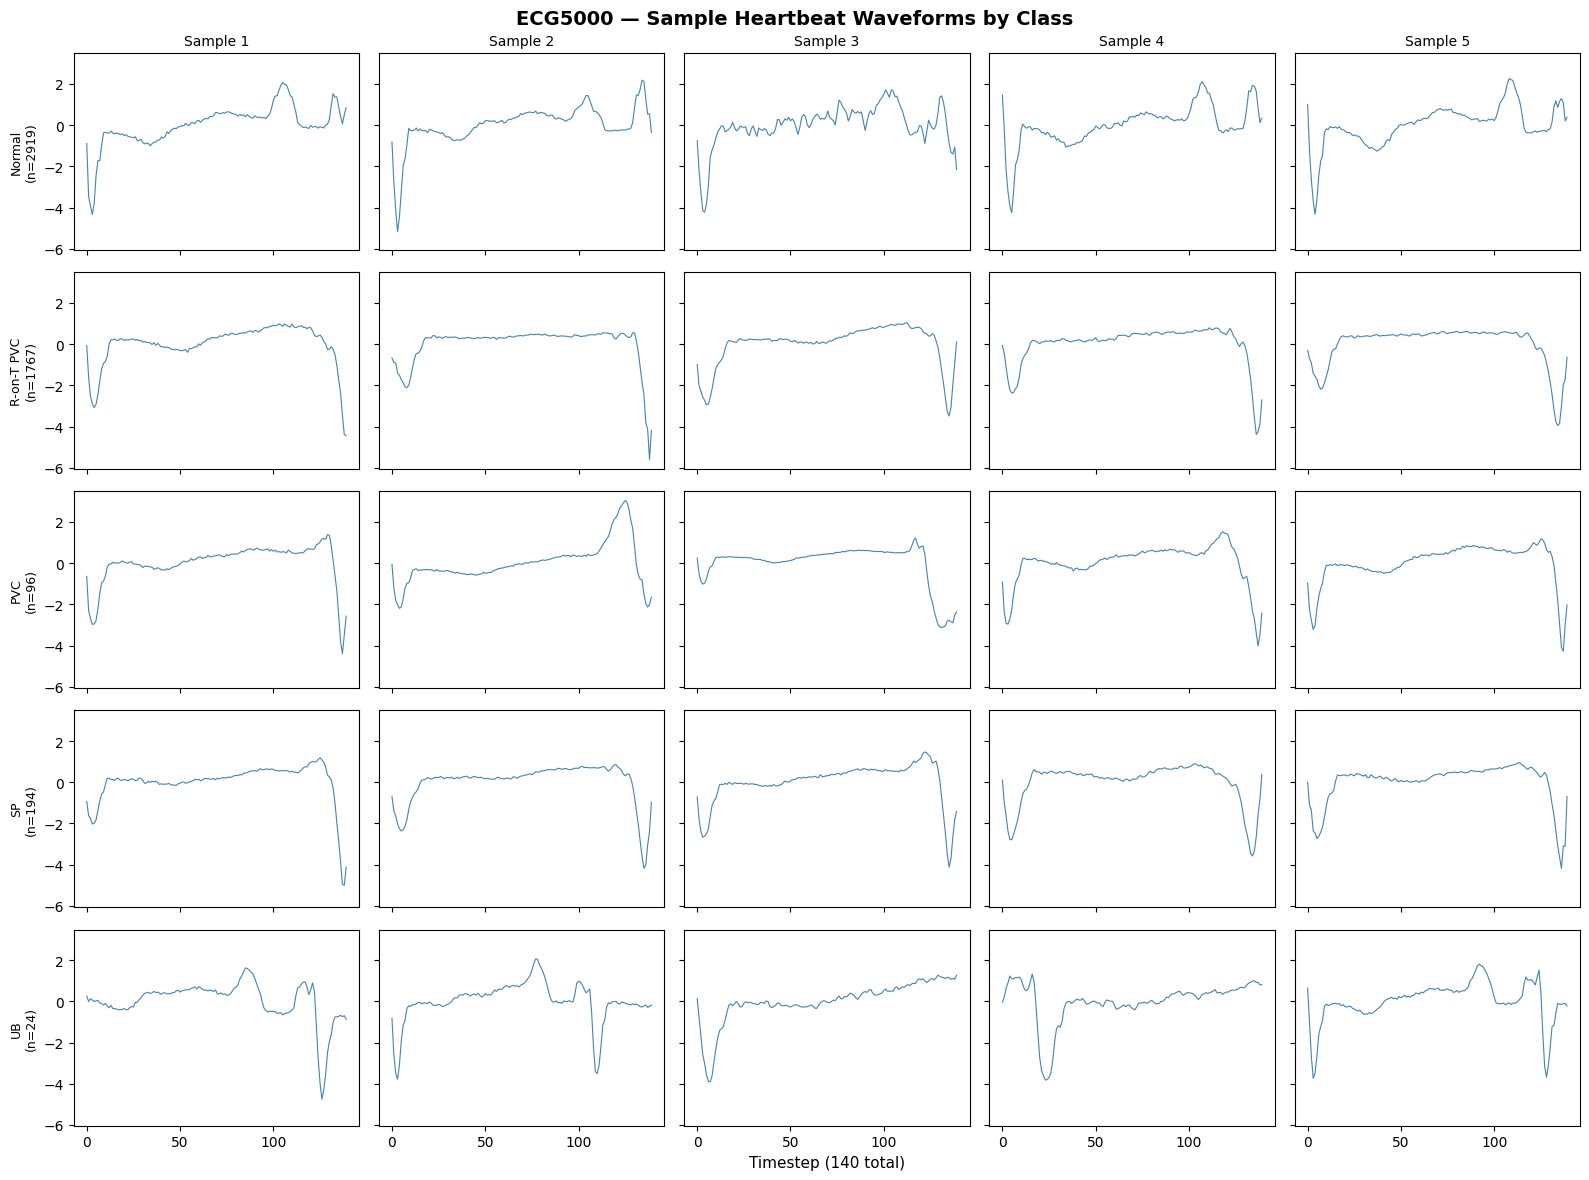


Key observations:
  - Normal (class 1): consistent QRS complex shape
  - R-on-T PVC (class 2): early depolarization, wider QRS
  - PVC (class 3): premature ventricular contraction pattern
  - SP (class 4): supraventricular premature beat
  - UB (class 5): only 24 samples, unclassifiable/borderline


In [4]:
# Step 3: [2/7] Sample ECG Waveforms
"""
Visualize sample heartbeats per class
Shows morphological differences the RNN needs to learn
Each row = one class, 5 random samples per class
"""

print("=" * 60)
print("[2/7] Sample ECG Waveforms by Class")
print("=" * 60)

rng = np.random.RandomState(113)

fig, axes = plt.subplots(5, 5, figsize=(16, 12), sharex=True, sharey=True)

for row, label in enumerate(sorted(np.unique(y_all))):
    mask = y_all == label
    class_samples = X_all[mask]
    indices = rng.choice(len(class_samples), size=min(5, len(class_samples)), replace=False)

    for col, idx in enumerate(indices):
        axes[row, col].plot(class_samples[idx], color='steelblue', linewidth=0.8)
        if col == 0:
            axes[row, col].set_ylabel(f'{label_map[label]}\n(n={mask.sum()})',
                                       fontsize=9)
        if row == 0:
            axes[row, col].set_title(f'Sample {col+1}', fontsize=10)

    # Fill remaining columns if class has < 5 samples
    for col in range(len(indices), 5):
        axes[row, col].axis('off')

axes[-1, 2].set_xlabel('Timestep (140 total)', fontsize=11)
plt.suptitle('ECG5000 — Sample Heartbeat Waveforms by Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_sample_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observations:")
print("  - Normal (class 1): consistent QRS complex shape")
print("  - R-on-T PVC (class 2): early depolarization, wider QRS")
print("  - PVC (class 3): premature ventricular contraction pattern")
print("  - SP (class 4): supraventricular premature beat")
print("  - UB (class 5): only 24 samples, unclassifiable/borderline")

[3/7] Signal Statistics + Class Prototypes


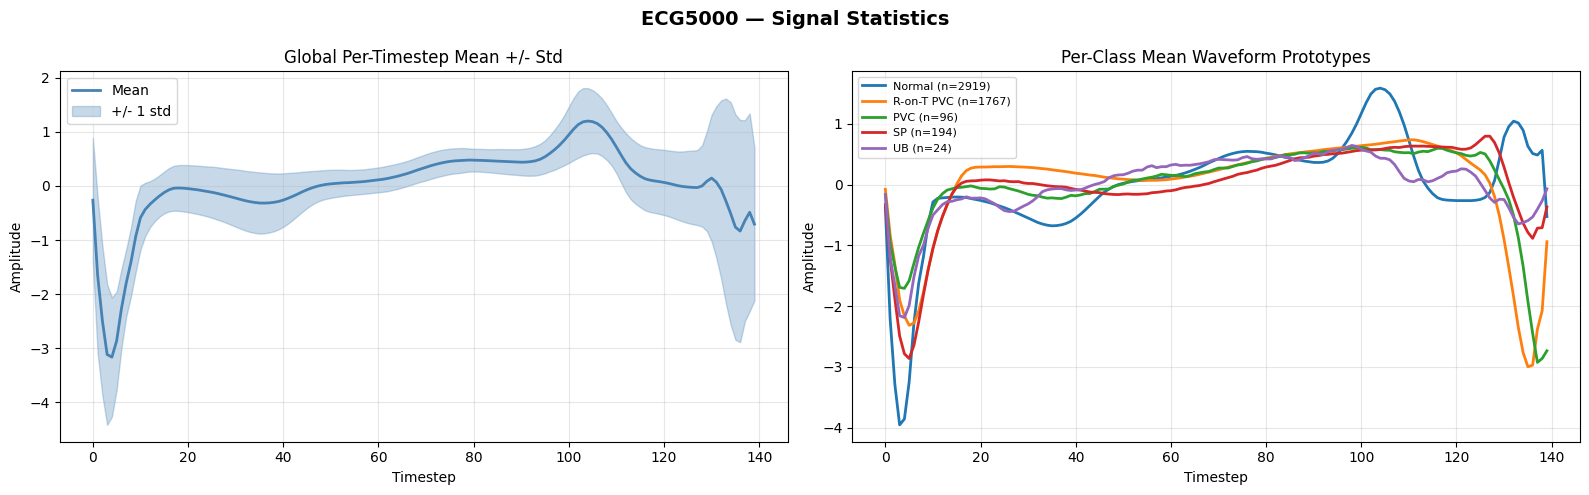


Global signal range: [-7.0904, 7.4021]
Per-timestep std range: [0.2098, 2.0860]
Peak class divergence at timestep: 136
  -> This is where the RNN should learn to differentiate classes


In [5]:
# Step 4: [3/7] Signal Statistics
"""
Per-timestep mean/std across all samples + per-class mean waveform prototypes
Shows where in the 140-timestep sequence the classes diverge most
"""

print("=" * 60)
print("[3/7] Signal Statistics + Class Prototypes")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: global per-timestep mean +/- std
global_mean = X_all.mean(axis=0)
global_std = X_all.std(axis=0)
timesteps = np.arange(140)

axes[0].plot(timesteps, global_mean, color='steelblue', linewidth=2, label='Mean')
axes[0].fill_between(timesteps, global_mean - global_std, global_mean + global_std,
                      alpha=0.3, color='steelblue', label='+/- 1 std')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Global Per-Timestep Mean +/- Std')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: per-class mean waveform (prototype)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for label, color in zip(sorted(np.unique(y_all)), colors):
    class_mean = X_all[y_all == label].mean(axis=0)
    axes[1].plot(timesteps, class_mean, color=color, linewidth=2,
                  label=f'{label_map[label]} (n={np.sum(y_all == label)})')

axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Per-Class Mean Waveform Prototypes')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ECG5000 — Signal Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_signal_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

# Where do classes diverge most?
class_means = np.array([X_all[y_all == label].mean(axis=0)
                         for label in sorted(np.unique(y_all))])
divergence = class_means.std(axis=0)  # std across class means at each timestep
peak_divergence = np.argmax(divergence)

print(f"\nGlobal signal range: [{X_all.min():.4f}, {X_all.max():.4f}]")
print(f"Per-timestep std range: [{global_std.min():.4f}, {global_std.max():.4f}]")
print(f"Peak class divergence at timestep: {peak_divergence}")
print(f"  -> This is where the RNN should learn to differentiate classes")


[4/7] Temporal Autocorrelation — Why RNN?


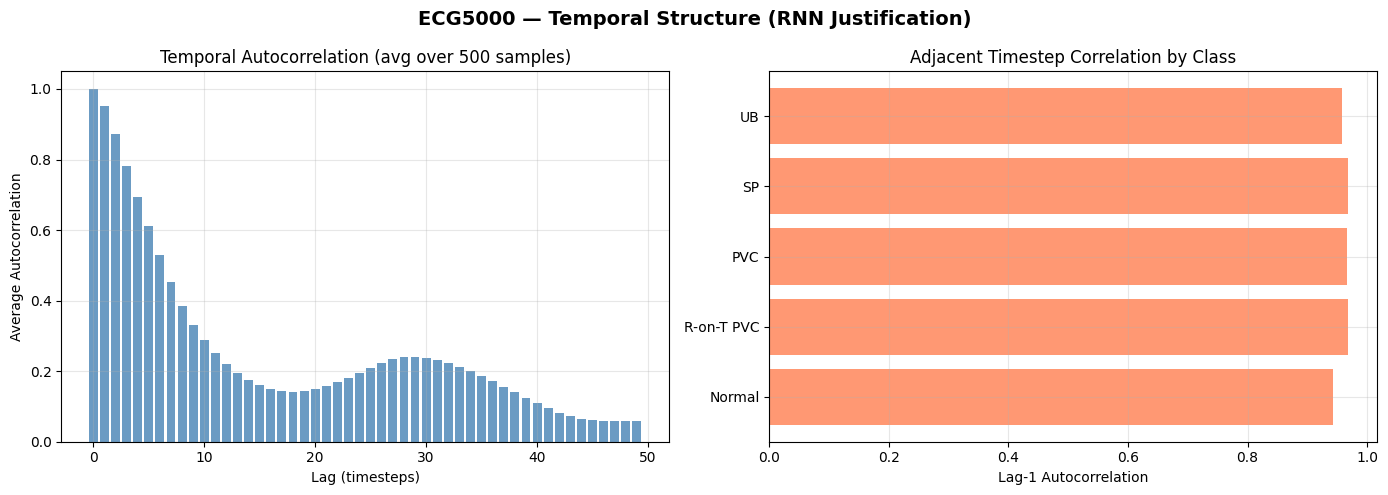


Lag-1 autocorrelation (adjacent timesteps):
  Normal: 0.9424
  R-on-T PVC: 0.9681
  PVC: 0.9669
  SP: 0.9681
  UB: 0.9574

Autocorrelation at lag=10: 0.2876
Autocorrelation at lag=25: 0.2094

High temporal correlation confirms RNN is appropriate:
  Adjacent timesteps carry redundant info -> RNN can exploit
  DNN would treat each of 140 features independently -> wasteful


In [6]:
# Step 5: [4/7] Temporal Autocorrelation
"""
Justify RNN over DNN: show high temporal structure in ECG signals
If adjacent timesteps are highly correlated, sequence models (RNN/GRU)
should outperform flat DNNs that treat each timestep independently
"""

print("=" * 60)
print("[4/7] Temporal Autocorrelation — Why RNN?")
print("=" * 60)

# Compute autocorrelation for a sample of signals
n_samples = 500
rng_auto = np.random.RandomState(113)
sample_idx = rng_auto.choice(len(X_all), n_samples, replace=False)
X_sample = X_all[sample_idx]

# Average autocorrelation across samples
max_lag = 50
autocorrs = np.zeros(max_lag)
for lag in range(max_lag):
    if lag == 0:
        autocorrs[lag] = 1.0
    else:
        corrs = []
        for sig in X_sample:
            c = np.corrcoef(sig[:-lag], sig[lag:])[0, 1]
            if not np.isnan(c):
                corrs.append(c)
        autocorrs[lag] = np.mean(corrs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: autocorrelation function
axes[0].bar(range(max_lag), autocorrs, color='steelblue', alpha=0.8)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_xlabel('Lag (timesteps)')
axes[0].set_ylabel('Average Autocorrelation')
axes[0].set_title('Temporal Autocorrelation (avg over 500 samples)')
axes[0].grid(True, alpha=0.3)

# Right: adjacent timestep correlation (lag=1) per class
lag1_by_class = {}
for label in sorted(np.unique(y_all)):
    class_sigs = X_all[y_all == label]
    corrs = [np.corrcoef(sig[:-1], sig[1:])[0, 1] for sig in class_sigs]
    lag1_by_class[label_map[label]] = np.mean(corrs)

names = list(lag1_by_class.keys())
vals = list(lag1_by_class.values())
axes[1].barh(range(len(names)), vals, color='coral', alpha=0.8)
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names)
axes[1].set_xlabel('Lag-1 Autocorrelation')
axes[1].set_title('Adjacent Timestep Correlation by Class')
axes[1].grid(True, alpha=0.3)

plt.suptitle('ECG5000 — Temporal Structure (RNN Justification)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_temporal_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLag-1 autocorrelation (adjacent timesteps):")
for name, val in lag1_by_class.items():
    print(f"  {name}: {val:.4f}")

print(f"\nAutocorrelation at lag=10: {autocorrs[10]:.4f}")
print(f"Autocorrelation at lag=25: {autocorrs[25]:.4f}")
print(f"\nHigh temporal correlation confirms RNN is appropriate:")
print(f"  Adjacent timesteps carry redundant info -> RNN can exploit")
print(f"  DNN would treat each of 140 features independently -> wasteful")

[5/7] Class Separability — 2D Projections


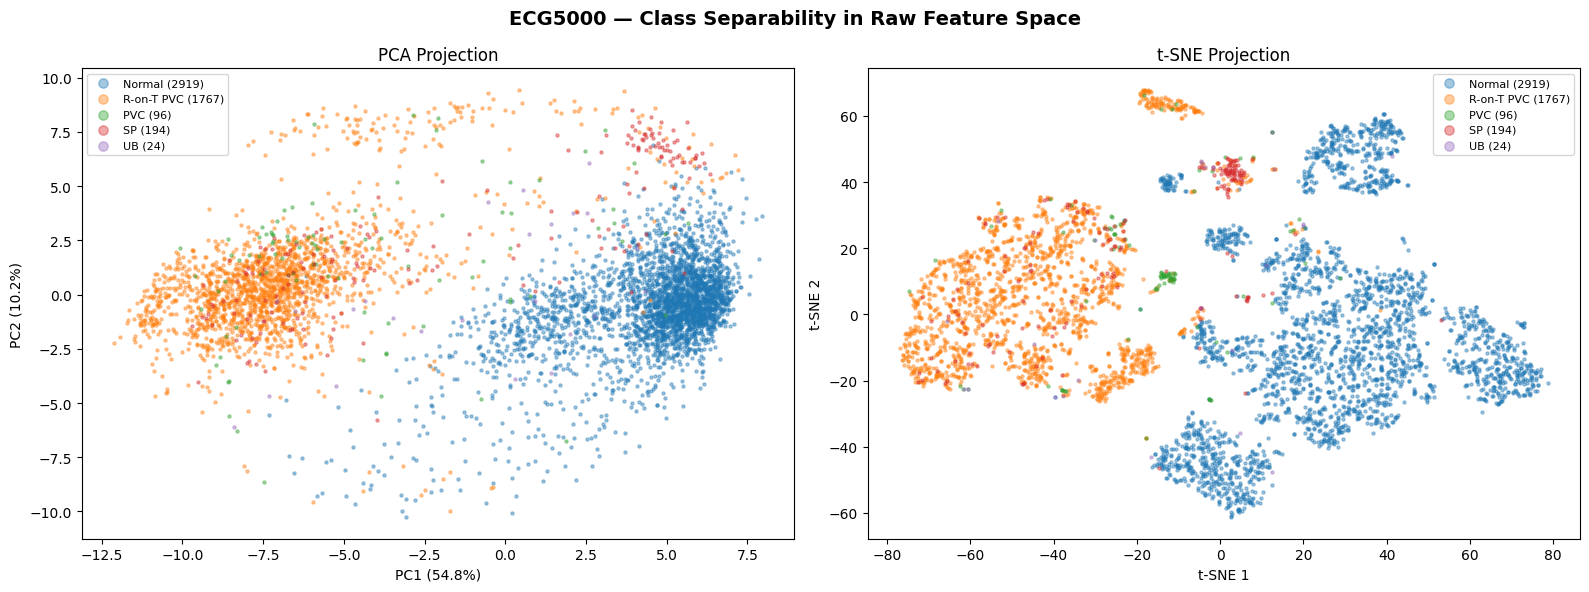


PCA variance explained: 65.1% (2 components)
  PC1: 54.8%
  PC2: 10.2%


In [7]:
# Step 6: [5/7] Class Separability
"""
t-SNE and PCA projections to see how separable classes are
in the raw feature space before any model training
"""

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

print("=" * 60)
print("[5/7] Class Separability — 2D Projections")
print("=" * 60)

# Subsample for t-SNE speed (use all 5000 — manageable)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# PCA projection
pca = PCA(n_components=2, random_state=113)
X_pca = pca.fit_transform(X_all)

for label, color in zip(sorted(np.unique(y_all)), colors):
    mask = y_all == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=5, alpha=0.4,
                     label=f'{label_map[label]} ({mask.sum()})')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA Projection')
axes[0].legend(fontsize=8, markerscale=3)

# t-SNE projection
tsne = TSNE(n_components=2, random_state=113, perplexity=30)
X_tsne = tsne.fit_transform(X_all)

for label, color in zip(sorted(np.unique(y_all)), colors):
    mask = y_all == label
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, s=5, alpha=0.4,
                     label=f'{label_map[label]} ({mask.sum()})')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE Projection')
axes[1].legend(fontsize=8, markerscale=3)

plt.suptitle('ECG5000 — Class Separability in Raw Feature Space',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_class_separability.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPCA variance explained: {pca.explained_variance_ratio_[:2].sum()*100:.1f}% (2 components)")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

In [8]:
# Step 7: [6/7] Train/Test Split Decision
"""
UCR default: 500 train / 4500 test (inverted for our purposes)
Decision: combine all 5000, stratified 80/20 re-split
This gives 4000 train / 1000 test with class ratios preserved
"""

from sklearn.model_selection import train_test_split

print("=" * 60)
print("[6/7] Train/Test Split Decision")
print("=" * 60)

print(f"\nUCR default split:")
print(f"  Train: {len(X_train_raw):,} ({len(X_train_raw)/len(X_all)*100:.0f}%)")
print(f"  Test:  {len(X_test_raw):,} ({len(X_test_raw)/len(X_all)*100:.0f}%)")
print(f"  Problem: 500 samples is too small for deep learning training")

print(f"\nProposed re-split (stratified 80/20):")
print(f"  Train: 4,000 (80%)")
print(f"  Test:  1,000 (20%)")

# Preview the re-split class distribution
X_tr_preview, X_te_preview, y_tr_preview, y_te_preview = train_test_split(
    X_all, y_all, test_size=0.2, random_state=113, stratify=y_all
)

print(f"\nStratified re-split class distribution:")
print(f"  {'Class':<15} | {'Train':>6} | {'Test':>6} | {'Train %':>8} | {'Test %':>8}")
print(f"  {'-'*15}-+-{'-'*6}-+-{'-'*6}-+-{'-'*8}-+-{'-'*8}")
for label in sorted(np.unique(y_all)):
    tr_count = np.sum(y_tr_preview == label)
    te_count = np.sum(y_te_preview == label)
    tr_pct = tr_count / len(y_tr_preview) * 100
    te_pct = te_count / len(y_te_preview) * 100
    print(f"  {label_map[label]:<15} | {tr_count:>6} | {te_count:>6} | {tr_pct:>7.1f}% | {te_pct:>7.1f}%")

print(f"\n  Total:          | {len(y_tr_preview):>6} | {len(y_te_preview):>6}")

# Class weights for training (inverse frequency)
class_counts = np.bincount(y_tr_preview)[1:]  # skip index 0 (labels are 1-indexed)
class_weights = len(y_tr_preview) / (len(np.unique(y_tr_preview)) * class_counts)
print(f"\nComputed class weights (inverse frequency):")
for label, weight in zip(sorted(np.unique(y_all)), class_weights):
    print(f"  {label_map[label]}: {weight:.4f}")

[6/7] Train/Test Split Decision

UCR default split:
  Train: 500 (10%)
  Test:  4,500 (90%)
  Problem: 500 samples is too small for deep learning training

Proposed re-split (stratified 80/20):
  Train: 4,000 (80%)
  Test:  1,000 (20%)

Stratified re-split class distribution:
  Class           |  Train |   Test |  Train % |   Test %
  ----------------+--------+--------+----------+---------
  Normal          |   2335 |    584 |    58.4% |    58.4%
  R-on-T PVC      |   1414 |    353 |    35.4% |    35.3%
  PVC             |     77 |     19 |     1.9% |     1.9%
  SP              |    155 |     39 |     3.9% |     3.9%
  UB              |     19 |      5 |     0.5% |     0.5%

  Total:          |   4000 |   1000

Computed class weights (inverse frequency):
  Normal: 0.3426
  R-on-T PVC: 0.5658
  PVC: 10.3896
  SP: 5.1613
  UB: 42.1053


In [9]:
# Step 8: [7/7] Summary
"""
Key findings from EDA -> preprocessing decisions
"""

print("=" * 60)
print("ECG5000 EDA — Summary of Findings")
print("=" * 60)

print("""
DATASET:
  - 5,000 heartbeat recordings, 140 timesteps each, univariate ECG
  - 5 classes: Normal, R-on-T PVC, PVC, SP, UB
  - Source: PhysioNet MIT-BIH via UCR Time Series Archive
  - UCR default split inverted (500 train / 4500 test) -> re-split 80/20

CLASS IMBALANCE:
  - 121.6x ratio (Normal=2919, UB=24)
  - Two majority classes: Normal (58.4%) + R-on-T PVC (35.3%) = 93.7%
  - Three minority classes: PVC (1.9%), SP (3.9%), UB (0.5%)
  - Class weights essential for training

SIGNAL CHARACTERISTICS:
  - Value range: [-7.09, 7.40] (already roughly centered)
  - High temporal autocorrelation: lag-1 > 0.94 for all classes
  - Peak class divergence at timestep 136 (end of sequence)
  - Clear morphological differences in class prototypes

CLASS SEPARABILITY:
  - PCA: 65.1% variance in 2 components, Normal vs R-on-T PVC separable on PC1
  - t-SNE: clear clusters for majority classes, minority classes scattered
  - Normal and R-on-T PVC well-separated, minority classes will be harder

PREPROCESSING DECISIONS:
  1. Combine all 5000, stratified 80/20 re-split (4000 train / 1000 test)
  2. StandardScaler fit on train only (per-feature, i.e. per-timestep)
  3. Reshape to (N, 140, 1) for RNN input (sequence_length, features)
  4. Remap labels from 1-indexed (1-5) to 0-indexed (0-4)
  5. Compute class weights (inverse frequency) for weighted loss
  6. No padding needed (all sequences are 140 timesteps)

RNN JUSTIFICATION:
  - High temporal autocorrelation -> sequence models exploit temporal structure
  - Peak divergence at timestep 136 -> model needs full sequence context
  - DNN would treat 140 features independently, ignoring temporal order
""")

ECG5000 EDA — Summary of Findings

DATASET:
  - 5,000 heartbeat recordings, 140 timesteps each, univariate ECG
  - 5 classes: Normal, R-on-T PVC, PVC, SP, UB
  - Source: PhysioNet MIT-BIH via UCR Time Series Archive
  - UCR default split inverted (500 train / 4500 test) -> re-split 80/20

CLASS IMBALANCE:
  - 121.6x ratio (Normal=2919, UB=24)
  - Two majority classes: Normal (58.4%) + R-on-T PVC (35.3%) = 93.7%
  - Three minority classes: PVC (1.9%), SP (3.9%), UB (0.5%)
  - Class weights essential for training

SIGNAL CHARACTERISTICS:
  - Value range: [-7.09, 7.40] (already roughly centered)
  - High temporal autocorrelation: lag-1 > 0.94 for all classes
  - Peak class divergence at timestep 136 (end of sequence)
  - Clear morphological differences in class prototypes

CLASS SEPARABILITY:
  - PCA: 65.1% variance in 2 components, Normal vs R-on-T PVC separable on PC1
  - t-SNE: clear clusters for majority classes, minority classes scattered
  - Normal and R-on-T PVC well-separated, min